## Setup, Imports, and Hyperparameters

In [ ]:
import os
import sys
import gc
import pickle
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
from torchvision.models import resnet18
from torchvision import transforms

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans, MiniBatchKMeans

# Ensure output directory exists
DATA_DIR = "./cifar10_data"
OUTPUT_DIR = "./output"
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True 

# Global Experiment Hyperparameters
N_REPETITIONS = 10
AL_ITERATIONS = 5
AL_BUDGET = 10
N_TRAIN = 50000

CLF_EPOCHS = 100
CLF_LR = 0.025
CLF_MOMENTUM = 0.9
CLF_WD = 5e-4
MAX_CLUSTERS = 500

def set_seed(seed: int):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def get_clf_transforms():
    train_tf = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
    ])
    test_tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
    ])
    return train_tf, test_tf

print(f"Device: {DEVICE} | Constants initialized.")

Device: cuda | Constants initialized.


## In-Memory Dataset and Optimized Training Loop

In [ ]:
class InMemoryCIFAR10(torch.utils.data.Dataset):
    def __init__(self, root, train=True):
        base_dataset = torchvision.datasets.CIFAR10(root=root, train=train, download=True)
        self.data = base_dataset.data
        self.targets = base_dataset.targets
        
    def __len__(self): return len(self.data)

class TransformSubset(torch.utils.data.Dataset):
    def __init__(self, in_memory_ds, indices, transform):
        self.in_memory_ds = in_memory_ds
        self.indices = indices
        self.transform = transform
        
    def __len__(self): return len(self.indices)
        
    def __getitem__(self, i):
        idx = self.indices[i]
        img = Image.fromarray(self.in_memory_ds.data[idx])
        target = self.in_memory_ds.targets[idx]
        if self.transform: img = self.transform(img)
        return img, target

train_ds_memory = InMemoryCIFAR10(root=DATA_DIR, train=True)
test_ds_memory  = InMemoryCIFAR10(root=DATA_DIR, train=False)

def train_classifier_optimized(labeled_indices: set, seed: int) -> float:
    """Optimized ResNet-18 training using Mixed Precision and 0 background workers."""
    set_seed(seed)
    train_tf, test_tf = get_clf_transforms()
    
    labeled_ds = TransformSubset(train_ds_memory, sorted(list(labeled_indices)), train_tf)
    test_ds    = TransformSubset(test_ds_memory, range(len(test_ds_memory)), test_tf)

    batch_size = min(64, len(labeled_indices))
    
    train_loader = DataLoader(labeled_ds, batch_size=batch_size, shuffle=True, 
                              num_workers=0, pin_memory=True, drop_last=(len(labeled_indices)>batch_size))
    test_loader  = DataLoader(test_ds, batch_size=256, shuffle=False, num_workers=0, pin_memory=True)

    model = resnet18(weights=None, num_classes=10).to(DEVICE)
    optimiser = optim.SGD(model.parameters(), lr=CLF_LR, momentum=CLF_MOMENTUM, weight_decay=CLF_WD, nesterov=True)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=CLF_EPOCHS)
    criterion = nn.CrossEntropyLoss()
    scaler = torch.amp.GradScaler('cuda')

    model.train()
    for _ in range(CLF_EPOCHS):
        for x, y in train_loader:
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            optimiser.zero_grad(set_to_none=True)
            with torch.amp.autocast('cuda'):
                loss = criterion(model(x), y)
            scaler.scale(loss).backward()
            scaler.step(optimiser)
            scaler.update()
        scheduler.step()

    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            with torch.amp.autocast('cuda'):
                preds = model(x).argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    del model, optimiser, scheduler, criterion, scaler, train_loader, test_loader
    gc.collect()
    torch.cuda.empty_cache()

    return 100.0 * correct / total

Files already downloaded and verified


/home/gr_g/projects/active-learning-tpcrp-cifar10/.venv_wsl2/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified


## Load Self-Supervised Embeddings

In [ ]:
emb_path = os.path.join(OUTPUT_DIR, "embeddings.npy")
labels_path = os.path.join(OUTPUT_DIR, "train_labels.npy")

if os.path.exists(emb_path) and os.path.exists(labels_path):
    embeddings = np.load(emb_path)
    train_labels = np.load(labels_path)
    print(f"Loaded embeddings shape: {embeddings.shape}")
else:
    raise FileNotFoundError("SimCLR embeddings not found. Please run the SimCLR pre-training step first.")

Loaded embeddings shape: (50000, 512)


## Original Active Learning Selection Functions

In [ ]:
def random_select(labeled_indices: set, budget: int, n_total: int, rng) -> list[int]:
    unlabeled = np.array([i for i in range(n_total) if i not in labeled_indices])
    return rng.choice(unlabeled, size=min(budget, len(unlabeled)), replace=False).tolist()

def uncertainty_select(labeled_indices: set, budget: int, clf_model, strategy: str) -> list[int]:
    unlabeled = np.array([i for i in range(N_TRAIN) if i not in labeled_indices])
    probs = clf_model.predict_proba(embeddings[unlabeled]) 

    if strategy == "uncertainty":
        scores = 1.0 - probs.max(axis=1)           
    elif strategy == "margin":
        sorted_p = np.sort(probs, axis=1)
        scores = 1.0 - (sorted_p[:, -1] - sorted_p[:, -2])  
    elif strategy == "entropy":
        scores = -np.sum(probs * np.log(probs + 1e-10), axis=1)  

    return unlabeled[np.argsort(scores)[-budget:]].tolist()

def tpcrp_select(embeddings: np.ndarray, labeled_indices: set, budget: int, rng) -> list[int]:
    N = len(embeddings)
    n_labeled = len(labeled_indices)
    n_clusters = max(min(n_labeled + budget, MAX_CLUSTERS), budget)

    km_seed = int(rng.integers(0, 2**31))
    km = KMeans(n_clusters=n_clusters, n_init=10, random_state=km_seed) if n_clusters <= 50 else MiniBatchKMeans(n_clusters=n_clusters, n_init=3, random_state=km_seed)
    cluster_ids = km.fit_predict(embeddings)

    covered = set(cluster_ids[list(labeled_indices)]) if labeled_indices else set()
    uncovered = [c for c in range(n_clusters) if c not in covered]
    cluster_sizes = np.bincount(cluster_ids, minlength=n_clusters)
    uncovered = [c for c in uncovered if cluster_sizes[c] >= 5]
    if not uncovered: uncovered = [c for c in range(n_clusters) if c not in covered]

    target_clusters = sorted(uncovered, key=lambda c: -cluster_sizes[c])[:budget]

    nbrs = NearestNeighbors(n_neighbors=21, metric="euclidean", n_jobs=-1).fit(embeddings)
    all_indices = np.arange(N)
    selected = []

    for c in target_clusters:
        candidates = [idx for idx in all_indices[cluster_ids == c].tolist() if idx not in labeled_indices]
        if not candidates: continue
        dists, _ = nbrs.kneighbors(embeddings[candidates], n_neighbors=min(21, len(candidates)))
        typicality = 1.0 / (dists[:, 1:].mean(axis=1) + 1e-10)
        selected.append(candidates[int(np.argmax(typicality))])

    return selected

## Modification: Topology-Aware Adaptive Typicality

In [ ]:
def tpcrp_select_adaptive_cosine(embeddings: np.ndarray, labeled_indices: set, budget: int, rng, alpha=0.1) -> list[int]:
    """
    Modifications:
    1. Cosine Distance: Respects L2-normalized hypersphere topology.
    2. Adaptive K: Scales typicality neighborhood proportional to local cluster size.
    """
    N = len(embeddings)
    n_labeled = len(labeled_indices)
    n_clusters = max(min(n_labeled + budget, MAX_CLUSTERS), budget)

    km_seed = int(rng.integers(0, 2**31))
    km = KMeans(n_clusters=n_clusters, n_init=10, random_state=km_seed) if n_clusters <= 50 else MiniBatchKMeans(n_clusters=n_clusters, n_init=3, random_state=km_seed)
    cluster_ids = km.fit_predict(embeddings)

    covered = set(cluster_ids[list(labeled_indices)]) if labeled_indices else set()
    uncovered = [c for c in range(n_clusters) if c not in covered]
    cluster_sizes = np.bincount(cluster_ids, minlength=n_clusters)
    uncovered = [c for c in uncovered if cluster_sizes[c] >= 5]
    if not uncovered: uncovered = [c for c in range(n_clusters) if c not in covered]

    target_clusters = sorted(uncovered, key=lambda c: -cluster_sizes[c])[:budget]

    # Pre-compute global KNN using cosine distance
    max_k = max([int(alpha * cluster_sizes[c]) for c in target_clusters] + [20])
    nbrs = NearestNeighbors(n_neighbors=min(max_k + 5, N), metric="cosine", n_jobs=-1).fit(embeddings)
    
    all_indices = np.arange(N)
    selected = []

    for c in target_clusters:
        candidates = [idx for idx in all_indices[cluster_ids == c].tolist() if idx not in labeled_indices]
        if not candidates: continue

        # adaptive K logic
        dynamic_k = int(alpha * len(candidates))
        k_use = max(5, min(dynamic_k, len(candidates) - 1))

        dists, _ = nbrs.kneighbors(embeddings[candidates], n_neighbors=k_use + 1)
        typicality = 1.0 / (dists[:, 1:k_use + 1].mean(axis=1) + 1e-10)
        selected.append(candidates[int(np.argmax(typicality))])

    return selected

## Load/Execute Standard Baselines & TPCRP

In [ ]:
def load_or_run_baselines():
    # 1. Load Original TPCRP & Random
    al_path = os.path.join(OUTPUT_DIR, "al_results.pkl")
    if os.path.exists(al_path):
        print(f"Loaded existing TPCRP and Random results from {al_path}")
        with open(al_path, "rb") as fh: saved = pickle.load(fh)
        tpcrp_accs, random_accs = saved["tpcrp"], saved["random"]
    else:
        raise FileNotFoundError("Missing al_results.pkl. Please run the original experiment first.")

    # 2. Load Uncertainty Baselines
    unc_path = os.path.join(OUTPUT_DIR, "uncertainty_results.pkl")
    if os.path.exists(unc_path):
        print(f"Loaded existing Uncertainty results from {unc_path}")
        with open(unc_path, "rb") as fh: saved = pickle.load(fh)
        unc_accs, margin_accs, entropy_accs = saved["uncertainty"], saved["margin"], saved["entropy"]
    else:
        raise FileNotFoundError("Missing uncertainty_results.pkl. Please run the corrected Uncertainty block first.")
        
    return tpcrp_accs, random_accs, unc_accs, margin_accs, entropy_accs

# Load all baseline runs
acc_tpcrp, acc_rand, acc_unc, acc_mar, acc_ent = load_or_run_baselines()

Loaded existing TPCRP and Random results from ./output/al_results.pkl
Loaded existing Uncertainty results from ./output/uncertainty_results.pkl


## Implement Topology-Aware Adaptive TPCRP

In [ ]:
mod_results_path = os.path.join(OUTPUT_DIR, "modified_results.pkl")

if os.path.exists(mod_results_path):
    print("Loading cached results for Modified TPCRP...")
    with open(mod_results_path, "rb") as fh:
        acc_mod = pickle.load(fh)["adaptive_cosine"]
else:
    print("=" * 60)
    print("Running model: Adaptive K + Cosine TPCRP")
    print("=" * 60)
    acc_mod = np.zeros((N_REPETITIONS, AL_ITERATIONS))

    for rep in range(N_REPETITIONS):
        rep_seed = 1000 + rep * 13
        rng = np.random.default_rng(rep_seed)
        print(f"─── Repetition {rep+1}/{N_REPETITIONS} ───")
        labeled_mod = set()

        for it in range(AL_ITERATIONS):
            clf_seed = rep_seed * 100 + it
            new_mod = tpcrp_select_adaptive_cosine(embeddings, labeled_mod, AL_BUDGET, rng, alpha=0.1)
            labeled_mod.update(new_mod)

            # Evaluate performance
            acc = train_classifier_optimized(labeled_mod, seed=clf_seed)
            acc_mod[rep, it] = acc
            print(f"  iter {it+1} | Modified TPCRP = {acc:.2f}%")

    with open(mod_results_path, "wb") as fh:
        pickle.dump({"adaptive_cosine": acc_mod}, fh)
    print(f"Saved modified results to {mod_results_path}")

Loading cached results for Modified TPCRP...


## Convert to csv for consistency

In [20]:
import os
import pickle
import csv
import numpy as np

OUTPUT_DIR = "output"  

# Define paths
mod_pkl_path = os.path.join(OUTPUT_DIR, "modified_results.pkl")
mod_csv_path = os.path.join(OUTPUT_DIR, "acc_mod_tpcrp_summary.csv")

if os.path.exists(mod_pkl_path):
    print(f"Reading {mod_pkl_path}...")
    with open(mod_pkl_path, "rb") as fh: 
        mod_saved = pickle.load(fh)
    
    # Extract the raw 10x5 matrix using the exact key from your notebook
    raw_data_matrix = np.array(mod_saved['adaptive_cosine'])
    n_reps = raw_data_matrix.shape[0]
    
    # Calculate Mean and Standard Error
    mean_acc = raw_data_matrix.mean(axis=0)
    se_acc = raw_data_matrix.std(axis=0, ddof=1) / np.sqrt(n_reps)
    
    # Save to the standardised 2-row CSV format
    with open(mod_csv_path, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(mean_acc.tolist())
        writer.writerow(se_acc.tolist())
        
    print(f"Converted and saved → {mod_csv_path}")
else:
    print(f"Error: Could not find {mod_pkl_path}. Please check the file path.")

Reading output/modified_results.pkl...
Converted and saved → output/acc_mod_tpcrp_summary.csv


## Calculate TV Distance for Modified TPCRP

In [ ]:
import os
import csv
import numpy as np

tv_mod_path = os.path.join(OUTPUT_DIR, "tv_mod_tpcrp_summary.csv")

def calc_tv(labeled_indices):
    """Calculates Total Variation distance from a perfectly balanced 10-class distribution."""
    if not labeled_indices: return 0.0
    # Ensure train_labels is an array
    labels_array = np.array(train_labels)
    dist = np.bincount(labels_array[list(labeled_indices)], minlength=10)
    return 0.5 * np.sum(np.abs((dist / dist.sum()) - (np.ones(10)/10.0)))

if os.path.exists(tv_mod_path):
    print("Loading cached TV distances for Modified TPCRP...")
else:
    print("Simulating selection to calculate TV Distances for Modified TPCRP...")
    all_reps_tvs = np.zeros((N_REPETITIONS, AL_ITERATIONS))

    set_seed(42)
    for rep in range(N_REPETITIONS):
        rng = np.random.default_rng(1000 + rep * 13)
        lab_mod = set()

        for it in range(AL_ITERATIONS):
            lab_mod.update(tpcrp_select_adaptive_cosine(embeddings, lab_mod, AL_BUDGET, rng))
            
            # Record the score
            all_reps_tvs[rep, it] = calc_tv(lab_mod)

    # Save summary CSV
    with open(tv_mod_path, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(all_reps_tvs.mean(axis=0))
        writer.writerow(all_reps_tvs.std(axis=0, ddof=1) / np.sqrt(N_REPETITIONS))

    print(f"Modified TPCRP TV distances calculated and saved -> {tv_mod_path}")

Simulating selection to calculate TV Distances for Modified TPCRP...
Modified TPCRP TV distances calculated and saved -> ./output/tv_mod_tpcrp_summary.csv


## Accuracy Graph

High-res Accuracy plot saved to: output/acc_all_methods_matplotlib.png


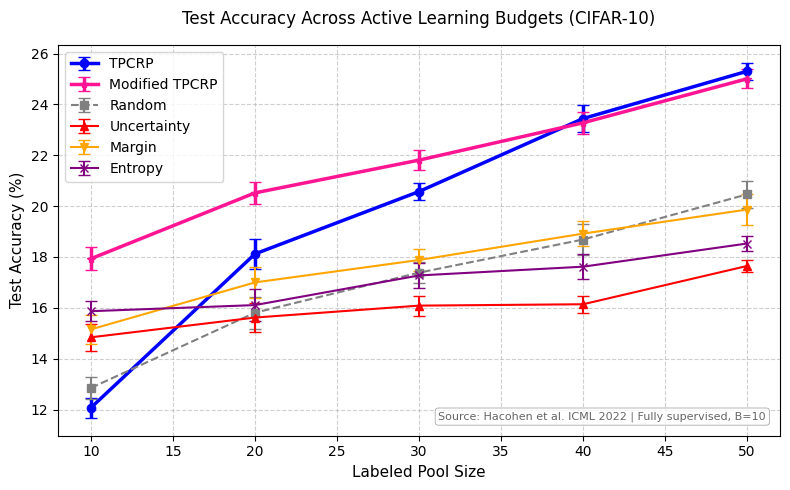

In [ ]:
import os
import csv
import numpy as np
import matplotlib.pyplot as plt

OUTPUT_DIR = "output"
AL_ITERATIONS = 5
AL_BUDGET = 10

# ─── 1. Loader for CSVs ───
def load_summary(strategy_name):
    """Loads the Mean (row 0) and Standard Error (row 1) from a summary CSV."""
    csv_path = os.path.join(OUTPUT_DIR, f"acc_{strategy_name}_summary.csv")
    with open(csv_path, 'r') as f:
        reader = csv.reader(f)
        rows = list(reader)
        mean_acc = np.array([float(x) for x in rows[0]])
        se_acc = np.array([float(x) for x in rows[1]])
    return mean_acc, se_acc

# ─── 2. Load Data ───
tpcrp_mean, tpcrp_se = load_summary('tpcrp')
random_mean, random_se = load_summary('random')
unc_mean, unc_se = load_summary('uncertainty')
mar_mean, mar_se = load_summary('margin')
ent_mean, ent_se = load_summary('entropy')
try:
    mod_mean, mod_se = load_summary('mod_tpcrp')
except FileNotFoundError:
    print("Notice: acc_mod_tpcrp_summary.csv not found. Plotting without it.")
    mod_mean, mod_se = None, None

# ─── 3. Generate the Plot ───
budgets = [AL_BUDGET + i * AL_BUDGET for i in range(AL_ITERATIONS)]

plt.figure(figsize=(8, 5))

# Plot all lines with Error Bars
plt.errorbar(budgets, tpcrp_mean, yerr=tpcrp_se, marker='o', label='TPCRP', linewidth=2.5, color='blue', capsize=4)

if mod_mean is not None:
    plt.errorbar(budgets, mod_mean, yerr=mod_se, marker='*', label='Modified TPCRP', linewidth=2.5, color='deeppink', capsize=4)

plt.errorbar(budgets, random_mean, yerr=random_se, marker='s', label='Random', linestyle='--', color='gray', capsize=4)
plt.errorbar(budgets, unc_mean, yerr=unc_se, marker='^', label='Uncertainty', color='red', capsize=4)
plt.errorbar(budgets, mar_mean, yerr=mar_se, marker='v', label='Margin', color='orange', capsize=4)
plt.errorbar(budgets, ent_mean, yerr=ent_se, marker='x', label='Entropy', color='purple', capsize=4)

# ─── 4. Formatting & Export ───
plt.title("Test Accuracy Across Active Learning Budgets (CIFAR-10)", fontsize=12, pad=15)
plt.xlabel("Labeled Pool Size", fontsize=11)
plt.ylabel("Test Accuracy (%)", fontsize=11)

# Source Annotation
plt.annotate('Source: Hacohen et al. ICML 2022 | Fully supervised, B=10', 
             xy=(1, 0), xycoords='axes fraction', 
             xytext=(-10, 10), textcoords='offset points',
             ha='right', va='bottom', fontsize=8, alpha=0.6,
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=0.5, alpha=0.8))

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plot_path = os.path.join(OUTPUT_DIR, "acc_all_methods_matplotlib.png")
plt.savefig(plot_path, dpi=300)
print(f"High-res Accuracy plot saved to: {plot_path}")

plt.show()

High-res plot saved to: output/tv_distance_all_methods.png


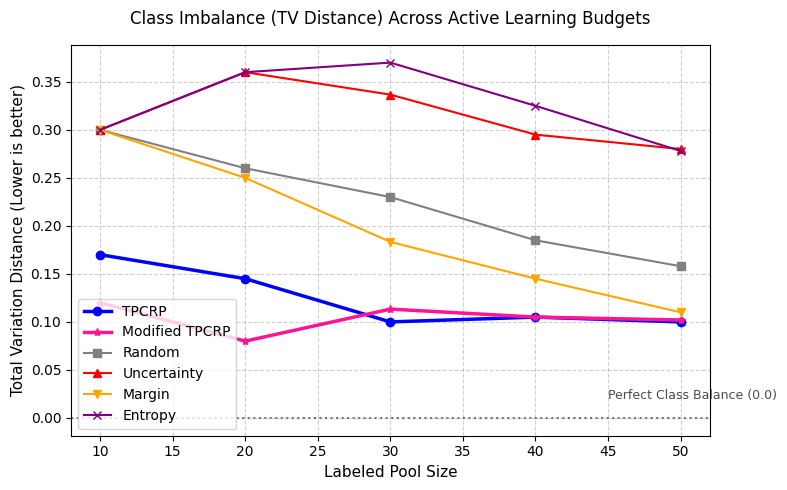

In [ ]:
import os
import csv
import numpy as np
import matplotlib.pyplot as plt

# 1. Load TPCRP and Random
tv_tpcrp_random = np.load(os.path.join(OUTPUT_DIR, "tv_distances.npz"))
tv_tpcrp  = tv_tpcrp_random["tpcrp"].reshape(N_REPETITIONS, AL_ITERATIONS)
tv_random = tv_tpcrp_random["random"].reshape(N_REPETITIONS, AL_ITERATIONS)

# 2. Load the Baselines
tv_baselines = np.load(os.path.join(OUTPUT_DIR, "baseline_tv_distances.npz"))
tv_unc = tv_baselines["unc"]
tv_mar = tv_baselines["mar"]
tv_ent = tv_baselines["ent"]

# 3. Load Modified TPCRP
tv_mod_path = os.path.join(OUTPUT_DIR, "tv_mod_tpcrp_summary.csv")
with open(tv_mod_path, 'r') as f:
    reader = csv.reader(f)
    rows = list(reader)
    tv_mod_mean = np.array([float(x) for x in rows[0]])

budgets = [AL_BUDGET + i * AL_BUDGET for i in range(AL_ITERATIONS)]


plt.figure(figsize=(8, 5))

plt.plot(budgets, tv_tpcrp.mean(axis=0), marker='o', label='TPCRP', linewidth=2.5, color='blue')
plt.plot(budgets, tv_mod_mean, marker='*', label='Modified TPCRP', linewidth=2.5, color='deeppink')
plt.plot(budgets, tv_random.mean(axis=0), marker='s', label='Random', color='gray')
plt.plot(budgets, tv_unc.mean(axis=0), marker='^', label='Uncertainty', color='red')
plt.plot(budgets, tv_mar.mean(axis=0), marker='v', label='Margin', color='orange')
plt.plot(budgets, tv_ent.mean(axis=0), marker='x', label='Entropy', color='purple')

plt.title("Class Imbalance (TV Distance) Across Active Learning Budgets", fontsize=12, pad=15)
plt.xlabel("Labeled Pool Size", fontsize=11)
plt.ylabel("Total Variation Distance (Lower is better)", fontsize=11)

plt.axhline(y=0.0, color='black', linestyle=':', alpha=0.5)
plt.text(budgets[-1]-5, 0.02, 'Perfect Class Balance (0.0)', color='black', alpha=0.7, fontsize=9)

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plot_path = os.path.join(OUTPUT_DIR, "tv_distance_all_methods.png")
plt.savefig(plot_path, dpi=300)
print(f"High-res plot saved to: {plot_path}")

plt.show()